# Tarefa 02

- Leia os enunciados com atenção
- Saiba que pode haver mais de uma resposta correta
- Insira novas células de código sempre que achar necessário
- Em caso de dúvidas, procure os monitores
- Divirta-se :)

#### 1. Carregue os dados da tarefa anterior

In [56]:
import yfinance as yf

ativos = ['AAPL', 'MSFT', 'TSLA']

dados = yf.download(ativos, period='2y')

# pegar só fechamento
dados = dados['Close']

# remover NaN
dados.dropna(inplace=True)

dados.head()

/tmp/ipykernel_55/2696129551.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ativos, period='2y')
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,TSLA
Date,,,
2024-03-27,171.746964,415.059326,179.830002
2024-03-28,169.933456,414.360107,175.789993
2024-04-01,168.496552,418.151855,175.220001
2024-04-02,167.317276,415.069244,166.630005
2024-04-03,168.119980,414.094208,168.380005


#### 2. Média móvel

1. Faça uma média móvel  em 90 dias dos valores de fechamento ajustados dos ativos que você escolheu
2. Utilizando a fução ```rolling()```, calcule o desvio pardão desses ativos ao longo do tempo, utilizando a mesma janela móvel do item acima
2. Monte um gráfico de linhas para as médias móveis dos ativos da sua base
4. Monte um gráfico de linhas para os desvios padrão em janela móvel
5. Compare os dois gráficos que você fez com o da tarefa anterior. Veja se eles apontam conclusões semelhantes quanto aos períodos de maior volatilidade (variação) dos ativos.

In [57]:
media_movel = dados.rolling(90).mean()

In [58]:
desvio_padrao = dados.rolling(90).std()

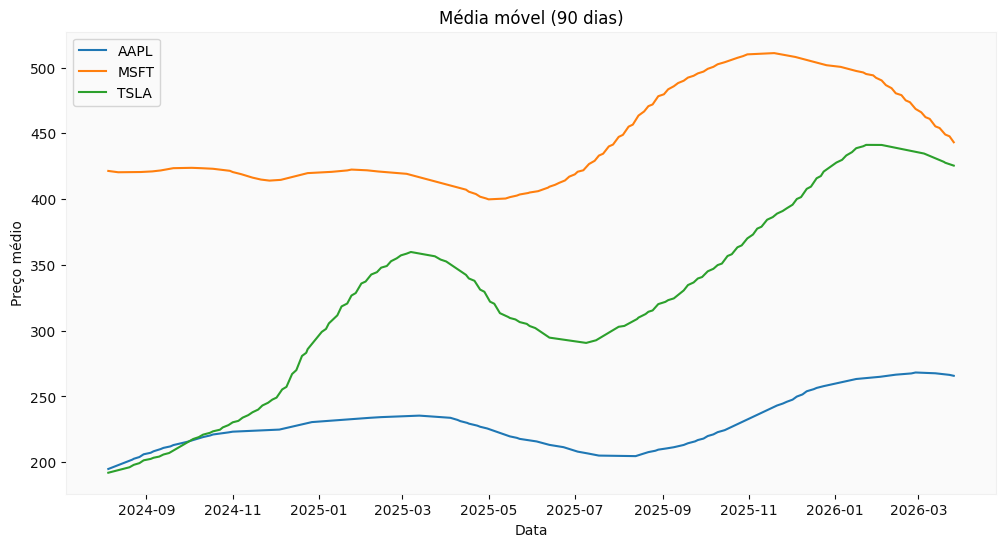

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for ativo in media_movel.columns:
    plt.plot(media_movel.index, media_movel[ativo], label=ativo)

plt.title('Média móvel (90 dias)')
plt.xlabel('Data')
plt.ylabel('Preço médio')
plt.legend()
plt.grid()

plt.show()

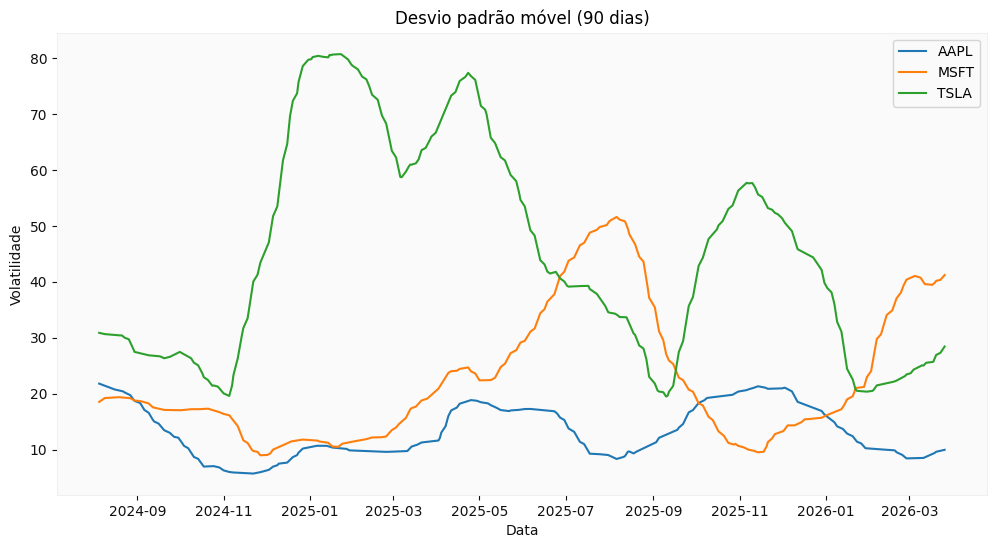

In [60]:
plt.figure(figsize=(12,6))

for ativo in desvio_padrao.columns:
    plt.plot(desvio_padrao.index, desvio_padrao[ativo], label=ativo)

plt.title('Desvio padrão móvel (90 dias)')
plt.xlabel('Data')
plt.ylabel('Volatilidade')
plt.legend()
plt.grid()

plt.show()

Foram calculadas médias móveis de 90 dias para os preços de fechamento dos ativos, permitindo observar a tendência de longo prazo.
Também foi calculado o desvio padrão em janela móvel de 90 dias, que representa a volatilidade dos ativos ao longo do tempo.
Os gráficos mostram que o ativo TSLA apresenta maior variabilidade, com valores mais elevados de desvio padrão, indicando maior volatilidade.
Ao comparar com a análise da tarefa anterior, observa-se consistência nos resultados, uma vez que os períodos de maior amplitude diária também coincidem com maiores valores de desvio padrão.
Portanto, ambos os métodos apontam conclusões semelhantes quanto aos períodos de maior volatilidade dos ativos.

#### 3. Gráfico de *candlestick*
1. Selecione o período dos últimos 60 dias (corridos) para um dos ativos da sua base
2. Monte um gráfico de *candlestick* para esses dados.

In [61]:
!pip install mplfinance

/tmp/ipykernel_55/820802192.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download('AAPL', period='60d')
[*********************100%***********************]  1 of 1 completed


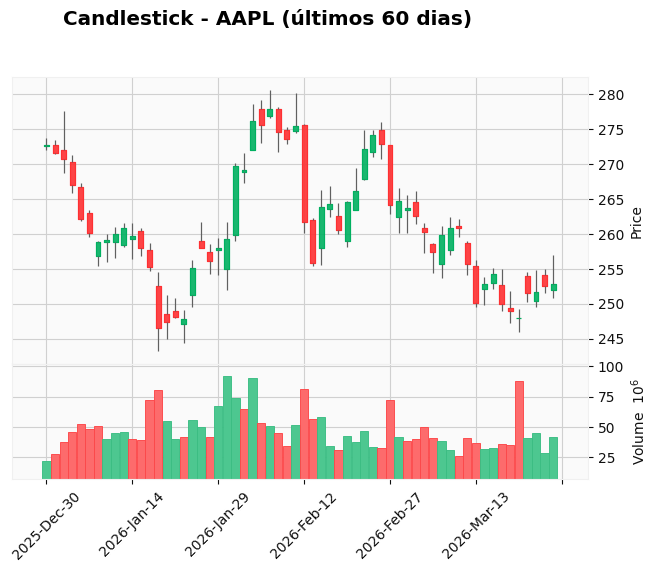

In [62]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd

# baixar dados
dados = yf.download('AAPL', period='60d')

# remover nível extra das colunas (ESSENCIAL)
if isinstance(dados.columns, pd.MultiIndex):
    dados.columns = dados.columns.droplevel(1)

# selecionar colunas corretas
dados = dados[['Open', 'High', 'Low', 'Close', 'Volume']]

# converter para float
dados = dados.astype(float)

# remover NaN
dados.dropna(inplace=True)

# plotar
mpf.plot(
    dados,
    type='candle',
    style='yahoo',
    title='Candlestick - AAPL (últimos 60 dias)',
    volume=True
)